# Task 4 — Pick the right chart, five times (Auto MPG)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "legend.frameon": False, "font.size": 10, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def finish(fig, title, subtitle=None, note=None, name=None):
    fig.tight_layout()
    tr = lambda y: offset_copy(fig.transFigure, fig=fig, y=y, units="points")
    if subtitle:
        fig.text(0.01, 1, subtitle, va="bottom", fontsize=10, color=INK_SOFT, transform=tr(4))
    fig.text(0.01, 1, title, va="bottom", fontsize=14, fontweight="bold", color=INK,
             transform=tr(22 if subtitle else 6))
    if note:
        fig.text(0.01, 0, note, va="top", fontsize=9, color=INK_MUTED, transform=tr(-4))
    if name:
        fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)
    plt.show()

In [2]:
cars = pd.read_csv(DATA / "mpg.csv")
print(cars.shape)
print(cars.isna().sum()[lambda s: s > 0])
cars["year"] = cars["model_year"] + 1900
cars["origin"] = cars["origin"].map({"usa": "USA", "europe": "Europe", "japan": "Japan"})
cars["origin"].value_counts()

(398, 9)
horsepower    6
dtype: int64


origin
USA       249
Japan      79
Europe     70
Name: count, dtype: int64

Only `horsepower` has missing values (6 cars). None of the five questions use horsepower, so I keep all
398 cars. `model_year` is stored as 70–82 so I turned it into 1970–1982.

In [3]:
ORIGIN_COL = {"USA": BLUE, "Europe": ORANGE, "Japan": AQUA}

## Q1. Did cars get more fuel-efficient between 1970 and 1982?

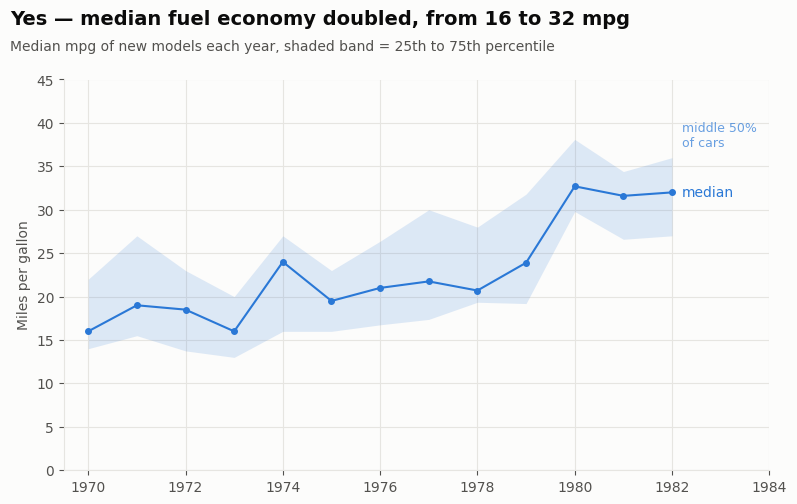

In [4]:
yr = cars.groupby("year")["mpg"].describe()

fig, ax = plt.subplots()
ax.fill_between(yr.index, yr["25%"], yr["75%"], color=BLUE, alpha=0.15, linewidth=0)
ax.plot(yr.index, yr["50%"], color=BLUE, marker="o", markersize=4)
ax.text(1982.2, yr["50%"].iloc[-1], "median", color=BLUE, va="center")
ax.text(1982.2, yr["75%"].iloc[-1] + 1, "middle 50%\nof cars", color=BLUE, alpha=0.7, va="bottom", fontsize=9)
ax.set_xlim(1969.5, 1984)
ax.set_ylim(0, 45)
ax.set_ylabel("Miles per gallon")

finish(fig, f"Yes — median fuel economy doubled, from {yr['50%'].iloc[0]:.0f} to {yr['50%'].iloc[-1]:.0f} mpg",
       "Median mpg of new models each year, shaded band = 25th to 75th percentile",
       name="task4_q1_trend")

**Why:** it's a trend over ordered years so a line chart, with a band to show the spread around the median.

## Q2. Do American, European and Japanese cars differ in fuel efficiency?

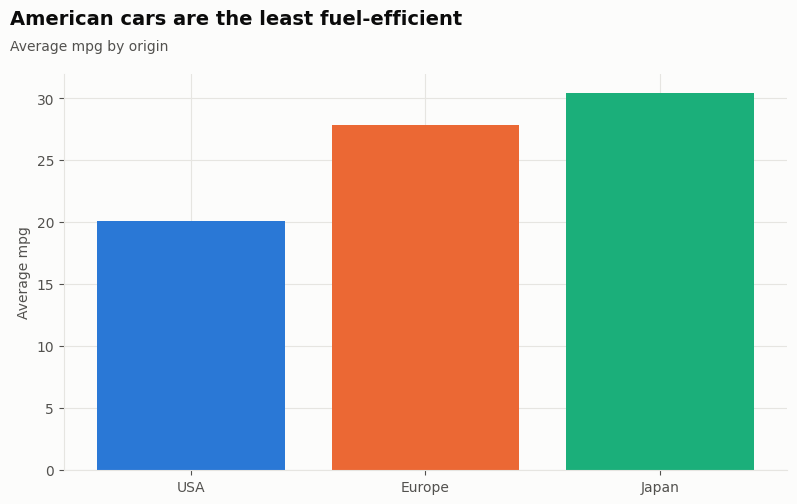

In [5]:
avg = cars.groupby("origin")["mpg"].mean().sort_values()

fig, ax = plt.subplots()
ax.bar(avg.index, avg.values, color=[ORIGIN_COL[o] for o in avg.index])
ax.set_ylabel("Average mpg")

finish(fig, "American cars are the least fuel-efficient", "Average mpg by origin", name="task4_q2_bar_v1")

**Why:** comparing a number across 3 categories → bar chart. (I come back to this one at the end — see
the redraw.)

## Q3. What's the relationship between weight and fuel efficiency?

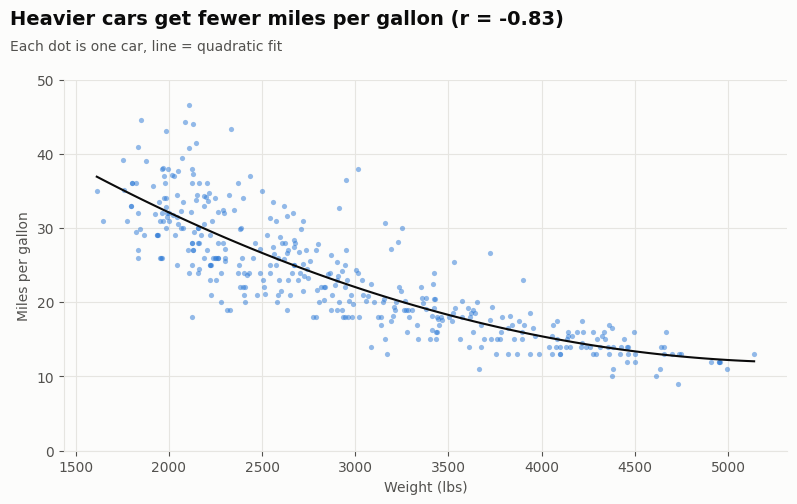

In [6]:
r = cars["weight"].corr(cars["mpg"])
b = np.polyfit(cars["weight"], cars["mpg"], 2)
xs = np.linspace(cars["weight"].min(), cars["weight"].max(), 100)

fig, ax = plt.subplots()
ax.scatter(cars["weight"], cars["mpg"], s=14, color=BLUE, alpha=0.5, linewidth=0)
ax.plot(xs, np.polyval(b, xs), color=INK, linewidth=1.5)
ax.set_xlabel("Weight (lbs)")
ax.set_ylabel("Miles per gallon")
ax.set_ylim(0, 50)

finish(fig, f"Heavier cars get fewer miles per gallon (r = {r:.2f})",
       "Each dot is one car, line = quadratic fit", name="task4_q3_scatter")

**Why:** two numeric variables → scatter plot. I added a curved fit because the relationship flattens out
for heavy cars instead of being a straight line.

## Q4. How is the number of cylinders distributed?

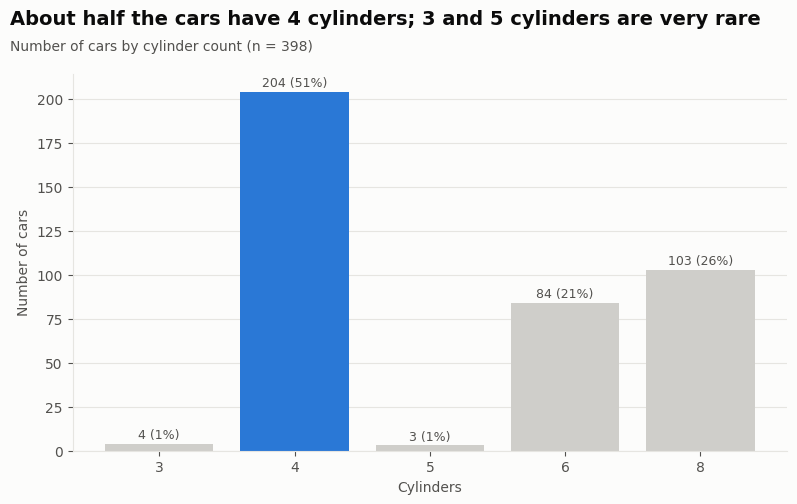

In [7]:
cyl = cars["cylinders"].value_counts().sort_index()
share = cyl / cyl.sum() * 100

fig, ax = plt.subplots()
bars = ax.bar(cyl.index.astype(str), cyl.values, color=[BLUE if c == 4 else QUIET for c in cyl.index])
for bar, n, p in zip(bars, cyl.values, share.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 3, f"{n} ({p:.0f}%)", ha="center", fontsize=9, color=INK_SOFT)
ax.set_xlabel("Cylinders")
ax.set_ylabel("Number of cars")
ax.grid(axis="x", visible=False)

finish(fig, f"About half the cars have 4 cylinders; 3 and 5 cylinders are very rare",
       f"Number of cars by cylinder count (n = {len(cars)})", name="task4_q4_cylinders")

**Why:** counts of a small set of categories → bar chart, kept in cylinder order since it's ordinal (not a
pie, there are 5 categories). Blue only for the bar the title is about.

## Q5. Is the improvement explained by weight? Did cars get lighter?

In [8]:
early = cars[cars["year"] <= 1974]
late = cars[cars["year"] >= 1978]

fit_early = np.polyfit(early["weight"], early["mpg"], 1)
fit_late = np.polyfit(late["weight"], late["mpg"], 1)
at3000 = [np.polyval(fit_early, 3000), np.polyval(fit_late, 3000)]

print("median weight: 1970-74 =", early["weight"].median(), " 1978-82 =", late["weight"].median())
print("median mpg:    1970-74 =", early["mpg"].median(), " 1978-82 =", late["mpg"].median())
print("predicted mpg at 3,000 lbs:", np.round(at3000, 1))

median weight: 1970-74 = 3053.5  1978-82 = 2617.5
median mpg:    1970-74 = 18.0  1978-82 = 28.9
predicted mpg at 3,000 lbs: [20.4 25.5]


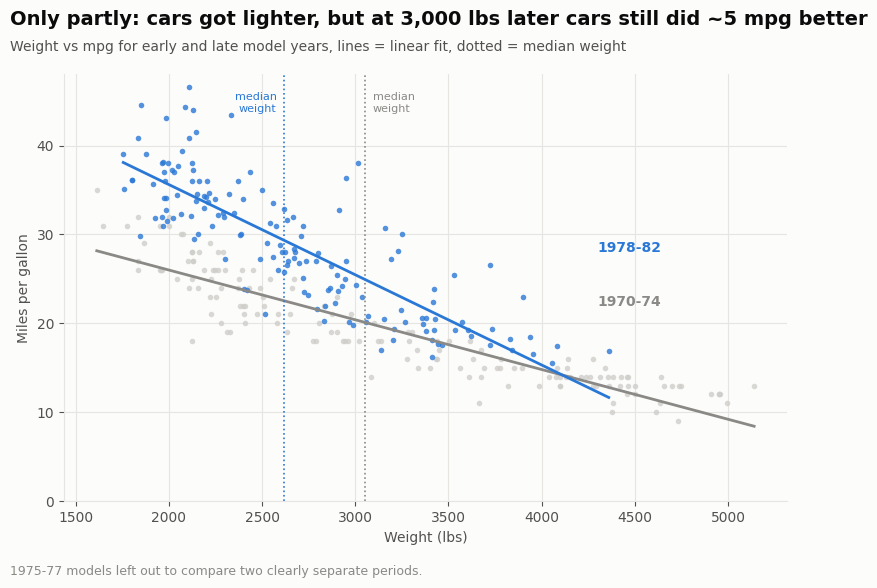

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for d, fit, dot, line in [(early, fit_early, QUIET, INK_MUTED), (late, fit_late, BLUE, BLUE)]:
    ax.scatter(d["weight"], d["mpg"], s=16, color=dot, alpha=0.8, linewidth=0)
    xs = np.linspace(d["weight"].min(), d["weight"].max(), 50)
    ax.plot(xs, np.polyval(fit, xs), color=line, linewidth=2)
    ax.axvline(d["weight"].median(), color=line, linestyle=":", linewidth=1.2)
ax.text(4300, 22, "1970-74", color=INK_MUTED, fontweight="bold")
ax.text(4300, 28, "1978-82", color=BLUE, fontweight="bold")
ax.text(early["weight"].median() + 40, 46, "median\nweight", color=INK_MUTED, fontsize=8, va="top")
ax.text(late["weight"].median() - 40, 46, "median\nweight", color=BLUE, fontsize=8, va="top", ha="right")
ax.set_xlabel("Weight (lbs)")
ax.set_ylabel("Miles per gallon")
ax.set_ylim(0, 48)

gain = at3000[1] - at3000[0]
finish(fig, f"Only partly: cars got lighter, but at 3,000 lbs later cars still did ~{gain:.0f} mpg better",
       "Weight vs mpg for early and late model years, lines = linear fit, dotted = median weight",
       "1975-77 models left out to compare two clearly separate periods.", name="task4_q5_weight")

**Why:** the question is whether the weight–mpg relationship moved, so a scatter of weight vs mpg split into
two periods. If lighter cars were the whole story, the late cars would just sit further left *on the same
line*. Instead the whole line moved up.

So: yes, cars got lighter (median weight dropped by about 440 lbs, from ~3,050 to ~2,620), which explains part of the
improvement. But at a typical weight (around 3,000 lbs) the 1978–82 cars still get about 5 more mpg than the 1970–74 ones (median mpg went up by about 11 overall),
so weight alone doesn't explain it — engines/technology got better too. (Also more of the late cars are
Japanese, which is mixed in here.)

## Redraw: the weakest chart is Q2

The Q2 bar chart only shows three averages. The question is whether the groups *differ*, and an average
hides how much they overlap. There are also very different numbers of cars in each group (249 US vs 70 and
79) and the chart doesn't say so.

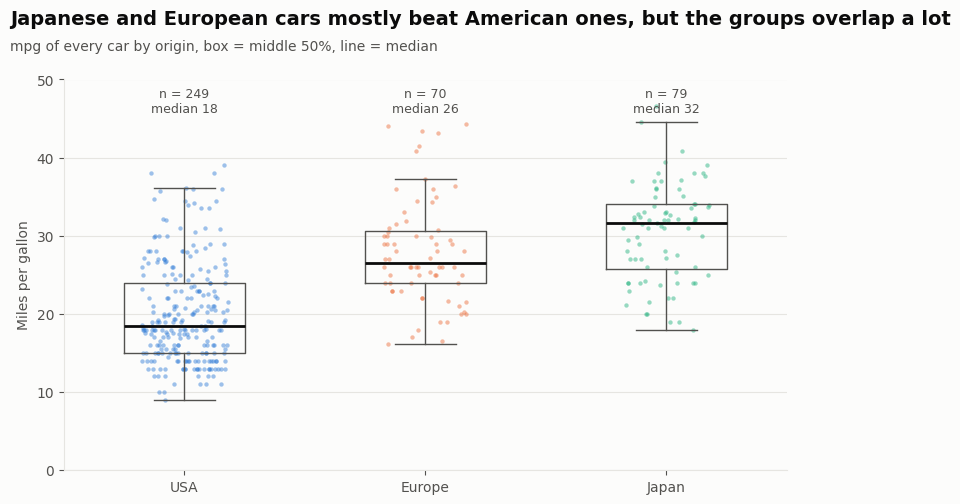

In [10]:
order = ["USA", "Europe", "Japan"]
rng = np.random.default_rng(1)

fig, ax = plt.subplots()
for i, o in enumerate(order):
    d = cars.loc[cars["origin"] == o, "mpg"]
    ax.scatter(i + rng.uniform(-0.18, 0.18, len(d)), d, s=10, color=ORIGIN_COL[o], alpha=0.45, linewidth=0)
    ax.boxplot(d, positions=[i], widths=0.5, showfliers=False,
               medianprops=dict(color=INK, linewidth=2), boxprops=dict(color=INK_SOFT),
               whiskerprops=dict(color=INK_SOFT), capprops=dict(color=INK_SOFT))
    ax.text(i, 49, f"n = {len(d)}\nmedian {d.median():.0f}", ha="center", va="top", fontsize=9, color=INK_SOFT)
ax.set_xticks(range(3), order)
ax.set_ylim(0, 50)
ax.set_ylabel("Miles per gallon")
ax.grid(axis="x", visible=False)

finish(fig, "Japanese and European cars mostly beat American ones, but the groups overlap a lot",
       "mpg of every car by origin, box = middle 50%, line = median", name="task4_q2_redraw")

What I changed:
- Bar of the mean → box plot with every car shown as a dot, so you can see the spread and overlap, not just one number.
- Median instead of mean (less affected by extreme cars).
- Added the sample size for each group.
- The title now says the finding with the nuance ("but they overlap") instead of just "American cars are worst".

Now you can see that 44 American cars (about 1 in 6) beat the median European car, and that the US group has a
much wider range (it has all the big V8s).